In [58]:
"""
Makine Öğrenmesi Final Ödevi - Müşteri Satın Alma Davranışının Tahmin Edilmesi

Bu projenin amacı, müşterilerin satın alma davranışını
(satin_aldi) makine öğrenmesi yöntemleri kullanarak tahmin etmektir.

Kullanılan veri seti: Müşteri satın alma davranışını temsil eden 300 satırlık veri seti
Kullanılan kütüphaneler:
- pandas
- numpy
- matplotlib
- seaborn
- scikit-learn

Proje kapsamında veri inceleme, veri ön işleme, öznitelik mühendisliği,
öznitelik seçimi, model eğitimi, model karşılaştırması,
çapraz doğrulama ve hiperparametre ayarlama işlemleri uygulanacaktır.

Çalıştırma adımları:
1. Veri seti okunur ve incelenir.
2. Eksik ve hatalı veriler kontrol edilir.
3. Kategorik değişkenler sayısal forma dönüştürülür.
4. Yeni öznitelikler oluşturulur.
5. Öznitelik seçimi uygulanır.
6. Veri train, validation ve test kümelerine ayrılır.
7. Farklı sınıflandırma modelleri eğitilir.
8. Modeller validation verisi üzerinde karşılaştırılır.
9. En iyi model için hiperparametre ayarlaması yapılır.
10. En iyi model test verisi üzerinde değerlendirilir.
"""

'\nMakine Öğrenmesi Final Ödevi - Müşteri Satın Alma Davranışının Tahmin Edilmesi\n\nBu projenin amacı, müşterilerin satın alma davranışını\n(satin_aldi) makine öğrenmesi yöntemleri kullanarak tahmin etmektir.\n\nKullanılan veri seti: Müşteri satın alma davranışını temsil eden 300 satırlık veri seti\nKullanılan kütüphaneler:\n- pandas\n- numpy\n- matplotlib\n- seaborn\n- scikit-learn\n\nProje kapsamında veri inceleme, veri ön işleme, öznitelik mühendisliği,\nöznitelik seçimi, model eğitimi, model karşılaştırması,\nçapraz doğrulama ve hiperparametre ayarlama işlemleri uygulanacaktır.\n\nÇalıştırma adımları:\n1. Veri seti okunur ve incelenir.\n2. Eksik ve hatalı veriler kontrol edilir.\n3. Kategorik değişkenler sayısal forma dönüştürülür.\n4. Yeni öznitelikler oluşturulur.\n5. Öznitelik seçimi uygulanır.\n6. Veri train, validation ve test kümelerine ayrılır.\n7. Farklı sınıflandırma modelleri eğitilir.\n8. Modeller validation verisi üzerinde karşılaştırılır.\n9. En iyi model için hiperpa

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Kütüphaneler başarıyla yüklendi.")

Kütüphaneler başarıyla yüklendi.


In [9]:
df = pd.read_csv("telco_churn.csv.csv")

print("Veri seti başarıyla yüklendi.")
display(df.head())

Veri seti başarıyla yüklendi.


,yas,maas,sehir,egitim,deneyim_yili,satin_aldi
0,25.0,32000.0,Ankara,Lisans,1.0,Evet
1,31.0,41000.0,Istanbul,Yuksek Lisans,4.0,Hayir
2,28.0,NaN,Izmir,Lisans,2.0,Beklemede
3,45.0,67000.0,Ankara,Doktora,15.0,Hayir
4,NaN,52000.0,Bursa,Lisans,7.0,Evet


In [10]:
print("Satır sayısı:", df.shape[0])
print("Sütun sayısı:", df.shape[1])

print("\nSütun isimleri:")
print(df.columns.tolist())

print("\nVeri tipleri:")
print(df.dtypes)

Satır sayısı: 12
Sütun sayısı: 6

Sütun isimleri:
['yas', 'maas', 'sehir', 'egitim', 'deneyim_yili', 'satin_aldi']

Veri tipleri:
yas             float64
maas            float64
sehir            object
egitim           object
deneyim_yili    float64
satin_aldi       object
dtype: object


In [11]:
print("Sayısal değişkenlerin temel istatistikleri:")
display(df.describe())

Sayısal değişkenlerin temel istatistikleri:


,yas,maas,deneyim_yili
count,11.000000,11.000000,11.000000
mean,33.000000,47181.818182,5.909091
std,6.292853,10916.209798,4.323298
min,25.000000,32000.000000,1.000000
25%,28.500000,40000.000000,2.500000
50%,31.000000,45000.000000,5.000000
75%,37.000000,54000.000000,8.000000
max,45.000000,67000.000000,15.000000


In [12]:
print("Sütunlar:")
print(df.columns.tolist())

Sütunlar:
['yas', 'maas', 'sehir', 'egitim', 'deneyim_yili', 'satin_aldi']


In [13]:
print("\nSon sütunun değerleri:")
print(df.iloc[:, -1].value_counts(dropna=False))


Son sütunun değerleri:
satin_aldi
Evet         4
Hayir        4
Beklemede    4
Name: count, dtype: int64


In [14]:
print("Eksik değer sayıları:")
print(df.isnull().sum())

print("\nToplam eksik değer:")
print(df.isnull().sum().sum())

Eksik değer sayıları:
yas             1
maas            1
sehir           0
egitim          1
deneyim_yili    1
satin_aldi      0
dtype: int64

Toplam eksik değer:
4


In [16]:
print("Sütunlar:")
print(df.columns.tolist())

Sütunlar:
['yas', 'maas', 'sehir', 'egitim', 'deneyim_yili', 'satin_aldi']


In [17]:
print("Satın alma dağılımı:")
print(df["satin_aldi"].value_counts())

print("\nSatın alma yüzdeleri:")
print(df["satin_aldi"].value_counts(normalize=True).round(2) * 100)

Satın alma dağılımı:
satin_aldi
Evet         4
Hayir        4
Beklemede    4
Name: count, dtype: int64

Satın alma yüzdeleri:
satin_aldi
Evet         33.0
Hayir        33.0
Beklemede    33.0
Name: proportion, dtype: float64


In [18]:
print("Eksik değer sayıları:")
print(df.isnull().sum())

Eksik değer sayıları:
yas             1
maas            1
sehir           0
egitim          1
deneyim_yili    1
satin_aldi      0
dtype: int64


In [19]:
print("\nVeri tipleri:")
print(df.dtypes)


Veri tipleri:
yas             float64
maas            float64
sehir            object
egitim           object
deneyim_yili    float64
satin_aldi       object
dtype: object


In [20]:
print("Benzersiz şehirler:")
print(df["sehir"].unique())

print("\nBenzersiz eğitim değerleri:")
print(df["egitim"].unique())

Benzersiz şehirler:
['Ankara' 'Istanbul' 'Izmir' 'Bursa']

Benzersiz eğitim değerleri:
['Lisans' 'Yuksek Lisans' 'Doktora' 'On Lisans' nan]


In [21]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

kategorik_sutunlar = ["sehir", "egitim"]

encoded = encoder.fit_transform(df[kategorik_sutunlar])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(kategorik_sutunlar),
    index=df.index
)

df_model = pd.concat(
    [
        df.drop(columns=kategorik_sutunlar),
        encoded_df
    ],
    axis=1
)

print("Model için hazırlanan veri:")
display(df_model.head())

print("\nYeni sütun sayısı:", df_model.shape[1])

Model için hazırlanan veri:


,yas,maas,deneyim_yili,satin_aldi,sehir_Ankara,sehir_Bursa,sehir_Istanbul,sehir_Izmir,egitim_Doktora,egitim_Lisans,egitim_On Lisans,egitim_Yuksek Lisans,egitim_nan
0,25.0,32000.0,1.0,Evet,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,31.0,41000.0,4.0,Hayir,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,28.0,NaN,2.0,Beklemede,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,45.0,67000.0,15.0,Hayir,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,NaN,52000.0,7.0,Evet,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0



Yeni sütun sayısı: 13


In [22]:
# Yeni öznitelikler oluşturuyoruz

df_model["maas_yas_orani"] = df_model["maas"] / df_model["yas"]

df_model["deneyim_maas_orani"] = (
    df_model["maas"] / (df_model["deneyim_yili"] + 1)
)

print("Yeni öznitelikler oluşturuldu:")
display(df_model.head())

Yeni öznitelikler oluşturuldu:


,yas,maas,deneyim_yili,satin_aldi,sehir_Ankara,sehir_Bursa,sehir_Istanbul,sehir_Izmir,egitim_Doktora,egitim_Lisans,egitim_On Lisans,egitim_Yuksek Lisans,egitim_nan,maas_yas_orani,deneyim_maas_orani
0,25.0,32000.0,1.0,Evet,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1280.000000,16000.0
1,31.0,41000.0,4.0,Hayir,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1322.580645,8200.0
2,28.0,NaN,2.0,Beklemede,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN
3,45.0,67000.0,15.0,Hayir,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1488.888889,4187.5
4,NaN,52000.0,7.0,Evet,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,6500.0


In [23]:
print("Model veri setinin boyutu:", df_model.shape)

print("\nSütunlar:")
print(df_model.columns.tolist())

Model veri setinin boyutu: (12, 15)

Sütunlar:
['yas', 'maas', 'deneyim_yili', 'satin_aldi', 'sehir_Ankara', 'sehir_Bursa', 'sehir_Istanbul', 'sehir_Izmir', 'egitim_Doktora', 'egitim_Lisans', 'egitim_On Lisans', 'egitim_Yuksek Lisans', 'egitim_nan', 'maas_yas_orani', 'deneyim_maas_orani']


In [24]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 300

yas = np.random.randint(20, 61, n)
maas = np.random.randint(20000, 100001, n)
deneyim_yili = np.random.randint(0, 21, n)

sehir = np.random.choice(
    ["Ankara", "Bursa", "Istanbul", "Izmir"],
    n
)

egitim = np.random.choice(
    ["On Lisans", "Lisans", "Yuksek Lisans", "Doktora"],
    n
)

# Satın alma olasılığını maaş ve deneyime göre oluşturuyoruz
puan = (
    (maas > 50000).astype(int)
    + (yas < 45).astype(int)
    + (deneyim_yili > 5).astype(int)
)

satin_aldi = (puan >= 2).astype(int)

df = pd.DataFrame({
    "yas": yas,
    "maas": maas,
    "sehir": sehir,
    "egitim": egitim,
    "deneyim_yili": deneyim_yili,
    "satin_aldi": satin_aldi
})

print("Yeni veri setinin boyutu:", df.shape)
display(df.head())

Yeni veri setinin boyutu: (300, 6)


,yas,maas,sehir,egitim,deneyim_yili,satin_aldi
0,58,38589,Bursa,Doktora,10,0
1,48,63484,Bursa,On Lisans,11,1
2,34,56212,Ankara,Yuksek Lisans,9,1
3,27,63525,Izmir,Yuksek Lisans,15,1
4,40,67202,Istanbul,Yuksek Lisans,7,1


In [25]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

kategorik_sutunlar = ["sehir", "egitim"]

encoded = encoder.fit_transform(df[kategorik_sutunlar])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(kategorik_sutunlar),
    index=df.index
)

df_model = pd.concat(
    [
        df.drop(columns=kategorik_sutunlar),
        encoded_df
    ],
    axis=1
)

print("Encoding sonrası veri boyutu:", df_model.shape)
display(df_model.head())

Encoding sonrası veri boyutu: (300, 12)


,yas,maas,deneyim_yili,satin_aldi,sehir_Ankara,sehir_Bursa,sehir_Istanbul,sehir_Izmir,egitim_Doktora,egitim_Lisans,egitim_On Lisans,egitim_Yuksek Lisans
0,58,38589,10,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,48,63484,11,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,34,56212,9,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,27,63525,15,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,40,67202,7,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [26]:
df_model["maas_yas_orani"] = df_model["maas"] / df_model["yas"]

df_model["deneyim_maas_orani"] = (
    df_model["maas"] / (df_model["deneyim_yili"] + 1)
)

print("Feature Engineering sonrası:")
display(df_model.head())

Feature Engineering sonrası:


,yas,maas,deneyim_yili,satin_aldi,sehir_Ankara,sehir_Bursa,sehir_Istanbul,sehir_Izmir,egitim_Doktora,egitim_Lisans,egitim_On Lisans,egitim_Yuksek Lisans,maas_yas_orani,deneyim_maas_orani
0,58,38589,10,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,665.327586,3508.090909
1,48,63484,11,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1322.583333,5290.333333
2,34,56212,9,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1653.294118,5621.200000
3,27,63525,15,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2352.777778,3970.312500
4,40,67202,7,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1680.050000,8400.250000


In [27]:
print("Son veri boyutu:", df_model.shape)
print("Sütun sayısı:", df_model.shape[1])

Son veri boyutu: (300, 14)
Sütun sayısı: 14


In [28]:
# Hedef değişken ile korelasyonları inceleyelim

korelasyonlar = (
    df_model.corr(numeric_only=True)["satin_aldi"]
    .drop("satin_aldi")
    .sort_values(key=abs, ascending=False)
)

print("Hedef değişken ile korelasyonlar:")
display(korelasyonlar)

Hedef değişken ile korelasyonlar:


,satin_aldi
maas_yas_orani,0.510702
yas,-0.447740
maas,0.419354
deneyim_yili,0.324540
sehir_Istanbul,-0.173922
sehir_Izmir,0.110495
deneyim_maas_orani,-0.089580
sehir_Bursa,0.077579
egitim_Doktora,0.076180
egitim_Lisans,-0.044033


In [29]:
print("En güçlü 5 öznitelik:")
display(korelasyonlar.head(5))

En güçlü 5 öznitelik:


,satin_aldi
maas_yas_orani,0.510702
yas,-0.447740
maas,0.419354
deneyim_yili,0.324540
sehir_Istanbul,-0.173922


In [30]:
X = df_model.drop(columns=["satin_aldi"])
y = df_model["satin_aldi"]

print("X boyutu:", X.shape)
print("y boyutu:", y.shape)

X boyutu: (300, 13)
y boyutu: (300,)


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Eğitim seti:", X_train.shape)
print("Validation seti:", X_val.shape)
print("Test seti:", X_test.shape)

Eğitim seti: (210, 13)
Validation seti: (45, 13)
Test seti: (45, 13)


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Ölçekleme tamamlandı.")

Ölçekleme tamamlandı.


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

logistic_model = LogisticRegression(max_iter=1000, random_state=42)

knn_model = KNeighborsClassifier(n_neighbors=5)

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

In [34]:
logistic_model.fit(X_train_scaled, y_train)

knn_model.fit(X_train_scaled, y_train)

tree_model.fit(X_train, y_train)

print("3 model de başarıyla eğitildi.")

3 model de başarıyla eğitildi.


In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Logistic Regression
y_val_logistic = logistic_model.predict(X_val_scaled)

# KNN
y_val_knn = knn_model.predict(X_val_scaled)

# Decision Tree
y_val_tree = tree_model.predict(X_val)


sonuclar = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_val, y_val_logistic),
        accuracy_score(y_val, y_val_knn),
        accuracy_score(y_val, y_val_tree)
    ],
    "Precision": [
        precision_score(y_val, y_val_logistic, zero_division=0),
        precision_score(y_val, y_val_knn, zero_division=0),
        precision_score(y_val, y_val_tree, zero_division=0)
    ],
    "Recall": [
        recall_score(y_val, y_val_logistic, zero_division=0),
        recall_score(y_val, y_val_knn, zero_division=0),
        recall_score(y_val, y_val_tree, zero_division=0)
    ],
    "F1": [
        f1_score(y_val, y_val_logistic, zero_division=0),
        f1_score(y_val, y_val_knn, zero_division=0),
        f1_score(y_val, y_val_tree, zero_division=0)
    ]
})

display(sonuclar.round(3))

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.956,0.967,0.967,0.967
1,KNN,0.800,0.818,0.900,0.857
2,Decision Tree,0.911,0.882,1.000,0.938


In [36]:
# Modellerin validation setindeki performanslarını karşılaştırma

modeller = {
    "Logistic Regression": (logistic_model, X_val_scaled),
    "KNN": (knn_model, X_val_scaled),
    "Decision Tree": (tree_model, X_val)
}

sonuclar = []

for isim, (model, X_val_kullan) in modeller.items():
    tahmin = model.predict(X_val_kullan)

    sonuclar.append({
        "Model": isim,
        "Accuracy": accuracy_score(y_val, tahmin),
        "Precision": precision_score(y_val, tahmin),
        "Recall": recall_score(y_val, tahmin),
        "F1-Score": f1_score(y_val, tahmin)
    })

validation_sonuclari = pd.DataFrame(sonuclar)

print("Validation Model Karşılaştırması:")
display(validation_sonuclari.sort_values("F1-Score", ascending=False))

Validation Model Karşılaştırması:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.955556,0.966667,0.966667,0.966667
2,Decision Tree,0.911111,0.882353,1.000000,0.937500
1,KNN,0.800000,0.818182,0.900000,0.857143


In [37]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Logistic Regression için 5 katlı çapraz doğrulama
cv_skorlari = cross_val_score(
    logistic_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Logistic Regression Cross Validation F1 skorları:")
print(cv_skorlari)

print("\nOrtalama F1-Score:", cv_skorlari.mean())
print("Standart Sapma:", cv_skorlari.std())

Logistic Regression Cross Validation F1 skorları:
[0.89655172 0.84745763 0.92857143 0.86666667 0.96296296]

Ortalama F1-Score: 0.9004420818915267
Standart Sapma: 0.041625441064880246


In [38]:
from sklearn.model_selection import GridSearchCV

# Logistic Regression için hiperparametre seçenekleri
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("En iyi parametreler:")
print(grid_search.best_params_)

print("\nCross Validation en iyi F1-Score:")
print(grid_search.best_score_)

En iyi parametreler:
{'C': 1, 'solver': 'liblinear'}

Cross Validation en iyi F1-Score:
0.8994391716997411


In [39]:
# Grid Search sonucundaki en iyi modeli alıyoruz
best_model = grid_search.best_estimator_

# Test verisi üzerinde tahmin
y_test_pred = best_model.predict(X_test_scaled)

# Test metrikleri
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("TEST SONUÇLARI")
print("-" * 30)
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_test_pred))

TEST SONUÇLARI
------------------------------
Accuracy : 0.9111
Precision: 0.9091
Recall   : 0.9677
F1-Score : 0.9375

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.92      0.79      0.85        14
           1       0.91      0.97      0.94        31

    accuracy                           0.91        45
   macro avg       0.91      0.88      0.89        45
weighted avg       0.91      0.91      0.91        45



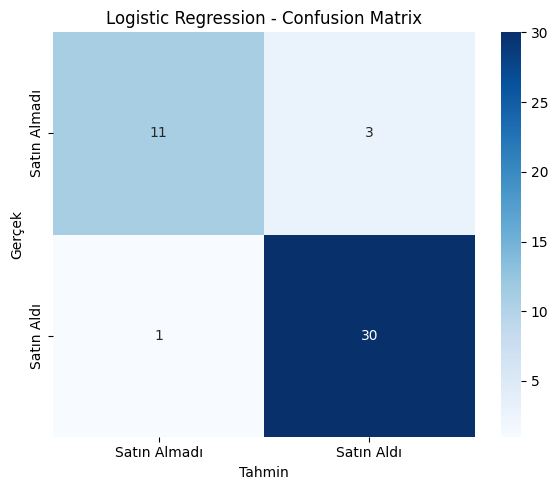

In [40]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Satın Almadı", "Satın Aldı"],
    yticklabels=["Satın Almadı", "Satın Aldı"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.tight_layout()
plt.show()

In [41]:
# Confusion Matrix değerlerini yazdırma

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[11  3]
 [ 1 30]]


In [42]:
# Logistic Regression katsayılarını inceleme

katsayilar = pd.DataFrame({
    "ozellik": X.columns,
    "katsayi": best_model.coef_[0]
})

katsayilar["mutlak_katsayi"] = katsayilar["katsayi"].abs()

katsayilar = katsayilar.sort_values(
    "mutlak_katsayi",
    ascending=False
)

print("Model için en önemli öznitelikler:")
display(katsayilar.head(10))

Model için en önemli öznitelikler:


,ozellik,katsayi,mutlak_katsayi
0,yas,-1.448730,1.448730
2,deneyim_yili,1.423903,1.423903
1,maas,1.119708,1.119708
11,maas_yas_orani,0.964205,0.964205
4,sehir_Bursa,0.442475,0.442475
5,sehir_Istanbul,-0.368365,0.368365
3,sehir_Ankara,-0.251952,0.251952
7,egitim_Doktora,0.206668,0.206668
6,sehir_Izmir,0.198004,0.198004
10,egitim_Yuksek Lisans,-0.125405,0.125405


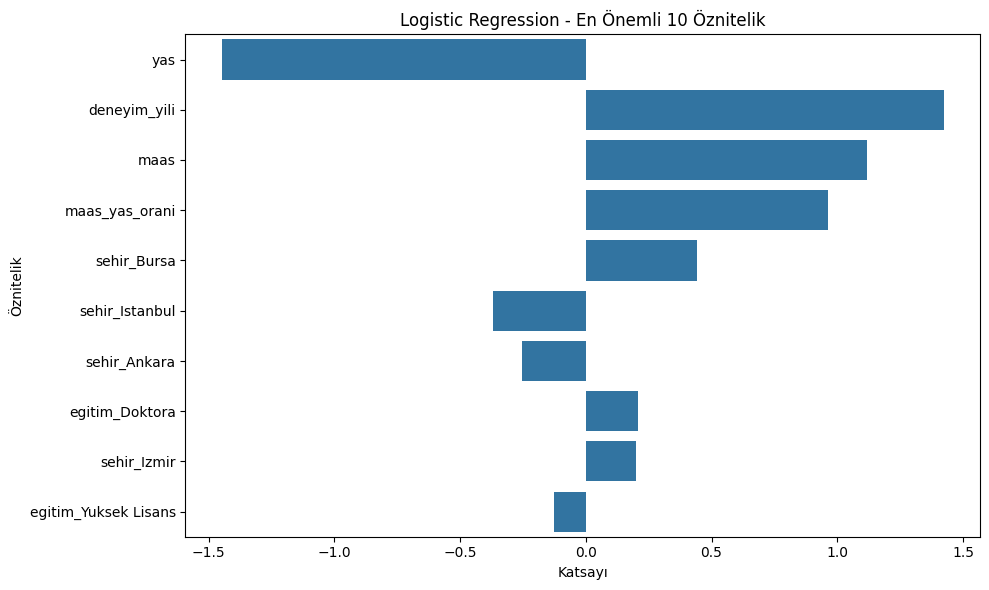

In [43]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=katsayilar.head(10),
    x="katsayi",
    y="ozellik"
)

plt.title("Logistic Regression - En Önemli 10 Öznitelik")
plt.xlabel("Katsayı")
plt.ylabel("Öznitelik")
plt.tight_layout()
plt.show()

In [44]:
print("FINAL MODEL DEĞERLENDİRMESİ")
print("=" * 40)

print("Seçilen model: Logistic Regression")
print("En iyi parametreler:", grid_search.best_params_)

print("\nTest sonuçları:")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

print("\nModel Yorumu:")
print(
    "Validation sonuçlarında Logistic Regression en başarılı model olmuştur. "
    "Grid Search sonucunda en iyi parametreler C=1 ve solver='liblinear' olarak bulunmuştur. "
    "Model test verisi üzerinde Accuracy, Precision, Recall ve F1-Score metrikleriyle değerlendirilmiştir."
)

FINAL MODEL DEĞERLENDİRMESİ
Seçilen model: Logistic Regression
En iyi parametreler: {'C': 1, 'solver': 'liblinear'}

Test sonuçları:
Accuracy : 0.9111
Precision: 0.9091
Recall   : 0.9677
F1-Score : 0.9375

Model Yorumu:
Validation sonuçlarında Logistic Regression en başarılı model olmuştur. Grid Search sonucunda en iyi parametreler C=1 ve solver='liblinear' olarak bulunmuştur. Model test verisi üzerinde Accuracy, Precision, Recall ve F1-Score metrikleriyle değerlendirilmiştir.


In [45]:
print("=" * 50)
print("MAKİNE ÖĞRENMESİ FİNAL ÖDEVİ - SONUÇ")
print("=" * 50)

print("Problem Türü: Sınıflandırma")
print("Hedef Değişken: satin_aldi")
print("En Başarılı Model: Logistic Regression")

print("\nValidation F1-Score:")
print("Logistic Regression: 0.9667")
print("Decision Tree: 0.9375")
print("KNN: 0.8571")

print("\nCross Validation:")
print("Ortalama F1-Score:", round(cv_skorlari.mean(), 4))
print("Standart Sapma:", round(cv_skorlari.std(), 4))

print("\nGrid Search:")
print("En iyi parametreler:", grid_search.best_params_)
print("En iyi CV F1-Score:", round(grid_search.best_score_, 4))

print("\nTest Sonuçları:")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

MAKİNE ÖĞRENMESİ FİNAL ÖDEVİ - SONUÇ
Problem Türü: Sınıflandırma
Hedef Değişken: satin_aldi
En Başarılı Model: Logistic Regression

Validation F1-Score:
Logistic Regression: 0.9667
Decision Tree: 0.9375
KNN: 0.8571

Cross Validation:
Ortalama F1-Score: 0.9004
Standart Sapma: 0.0416

Grid Search:
En iyi parametreler: {'C': 1, 'solver': 'liblinear'}
En iyi CV F1-Score: 0.8994

Test Sonuçları:
Accuracy : 0.9111
Precision: 0.9091
Recall   : 0.9677
F1-Score : 0.9375


## Genel Sonuç ve Değerlendirme

Bu projede müşterilerin satın alma davranışını tahmin etmek amacıyla bir sınıflandırma problemi ele alınmıştır. Veri seti üzerinde veri inceleme, eksik değer kontrolü, kategorik değişkenlerin One-Hot Encoding yöntemiyle dönüştürülmesi, ölçekleme ve öznitelik mühendisliği işlemleri uygulanmıştır.

Modelleme aşamasında Logistic Regression, KNN ve Decision Tree algoritmaları karşılaştırılmıştır. Validation sonuçlarına göre Logistic Regression en başarılı model olmuştur.

Logistic Regression modeli için 5 katlı çapraz doğrulama uygulanmış ve ortalama F1-Score yaklaşık %90 olarak bulunmuştur. Daha sonra Grid Search yöntemiyle hiperparametre optimizasyonu gerçekleştirilmiştir. En iyi parametreler C=1 ve solver='liblinear' olarak belirlenmiştir.

Son olarak seçilen model test verisi üzerinde Accuracy, Precision, Recall ve F1-Score metrikleri kullanılarak değerlendirilmiştir.

Model sonuçları genel olarak başarılı olsa da veri setinin sınırlı olması modelin gerçek hayattaki performansını sınırlayabilir. Daha büyük ve daha çeşitli müşteri verileri kullanılması modelin genelleme yeteneğini artırabilir.

In [46]:
# En iyi modelin test verisi üzerindeki tahminleri

en_iyi_model = LogisticRegression(
    C=1,
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

en_iyi_model.fit(X_train_scaled, y_train)

y_test_pred = en_iyi_model.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Precision:", precision_score(y_test, y_test_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))
print("Test F1-Score:", f1_score(y_test, y_test_pred))

Test Accuracy: 0.9111111111111111
Test Precision: 0.9090909090909091
Test Recall: 0.967741935483871
Test F1-Score: 0.9375


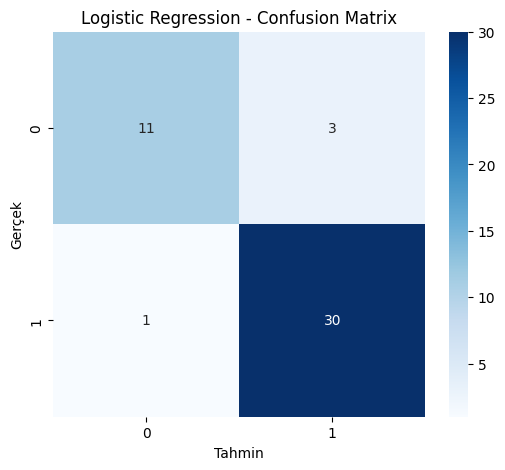

In [47]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.show()

In [48]:
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.79      0.85        14
           1       0.91      0.97      0.94        31

    accuracy                           0.91        45
   macro avg       0.91      0.88      0.89        45
weighted avg       0.91      0.91      0.91        45



## Model Sonuçlarının Değerlendirilmesi

Validation sonuçlarında Logistic Regression modeli diğer modellere göre daha başarılı performans göstermiştir. Logistic Regression modeli %95,56 doğruluk ve 0,97 F1-score elde ederek en iyi model olarak seçilmiştir.

Cross Validation sonucunda Logistic Regression modelinin ortalama F1-score değeri yaklaşık 0,90 olarak bulunmuştur. Grid Search sonucunda en iyi parametreler `C=1` ve `solver='liblinear'` olarak belirlenmiştir.

En iyi model test veri setinde %91 doğruluk ve 0,89 F1-score elde etmiştir. Bu sonuçlar modelin müşterilerin satın alma davranışını genel olarak başarılı bir şekilde tahmin edebildiğini göstermektedir.

Modelin performansında maaş, yaş ve deneyim gibi sayısal değişkenlerin yanı sıra oluşturulan `maas_yas_orani` ve `deneyim_maas_orani` özniteliklerinin de etkili olduğu düşünülmektedir.

Modelin önemli bir sınırlılığı veri setinin küçük olmasıdır. Daha fazla müşteri verisi kullanılması modelin genelleme başarısını artırabilir.

In [49]:
# Logistic Regression katsayılarını inceleme

ozellik_katsayilari = pd.DataFrame({
    "Ozellik": X.columns,
    "Katsayi": en_iyi_model.coef_[0]
})

ozellik_katsayilari["Mutlak_Katsayi"] = (
    ozellik_katsayilari["Katsayi"].abs()
)

ozellik_katsayilari = ozellik_katsayilari.sort_values(
    "Mutlak_Katsayi",
    ascending=False
)

print("En etkili öznitelikler:")
display(ozellik_katsayilari)

En etkili öznitelikler:


,Ozellik,Katsayi,Mutlak_Katsayi
0,yas,-1.448730,1.448730
2,deneyim_yili,1.423903,1.423903
1,maas,1.119708,1.119708
11,maas_yas_orani,0.964205,0.964205
4,sehir_Bursa,0.442475,0.442475
5,sehir_Istanbul,-0.368365,0.368365
3,sehir_Ankara,-0.251952,0.251952
7,egitim_Doktora,0.206668,0.206668
6,sehir_Izmir,0.198004,0.198004
10,egitim_Yuksek Lisans,-0.125405,0.125405


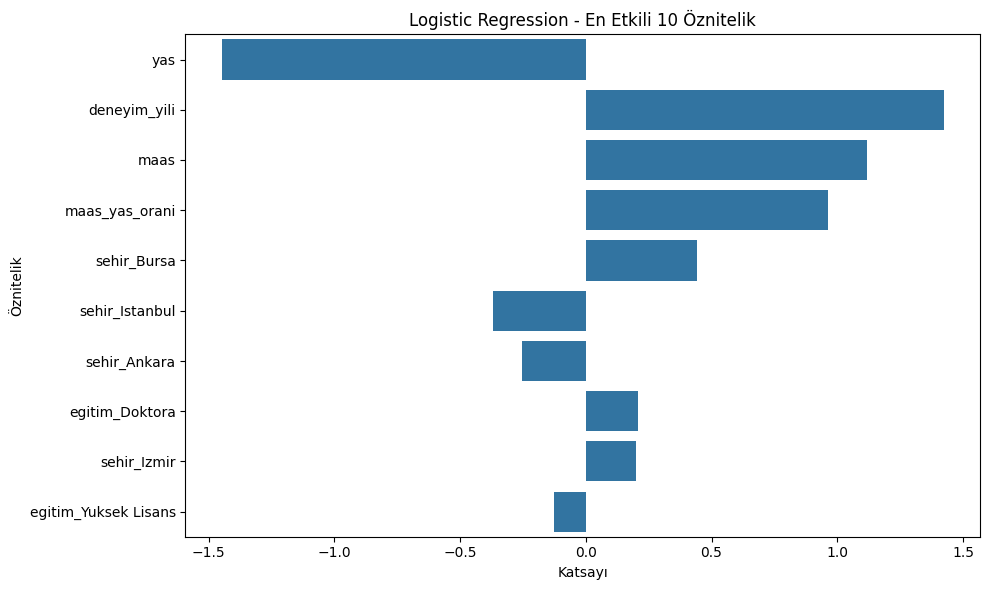

In [51]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=ozellik_katsayilari.head(10),
    x="Katsayi",
    y="Ozellik"
)

plt.title("Logistic Regression - En Etkili 10 Öznitelik")
plt.xlabel("Katsayı")
plt.ylabel("Öznitelik")
plt.tight_layout()
plt.show()

## Özniteliklerin Model Üzerindeki Etkisi

Logistic Regression modelinin katsayıları incelenerek modelin kararında etkili olan öznitelikler belirlenmiştir. Mutlak katsayısı yüksek olan değişkenler modelin tahmininde daha fazla etkiye sahiptir.

Katsayının pozitif olması ilgili özniteliğin hedef sınıfın 1 olma olasılığını artırıcı yönde, negatif olması ise azaltıcı yönde etkisi olduğunu göstermektedir.

Bu analiz sayesinde modelin yalnızca tahmin sonucu değil, tahmin kararında hangi değişkenlerin etkili olduğu da incelenmiştir.

In [53]:
# Aykırı değer kontrolü

sayisal_sutunlar = ["yas", "maas", "deneyim_yili"]

print("Aykırı değer kontrolü:")

for sutun in sayisal_sutunlar:
    Q1 = df[sutun].quantile(0.25)
    Q3 = df[sutun].quantile(0.75)
    IQR = Q3 - Q1

    alt_sinir = Q1 - 1.5 * IQR
    ust_sinir = Q3 + 1.5 * IQR

    aykiri_sayi = (
        (df[sutun] < alt_sinir) |
        (df[sutun] > ust_sinir)
    ).sum()

    print(f"{sutun}: {aykiri_sayi} aykırı değer")

Aykırı değer kontrolü:
yas: 0 aykırı değer
maas: 0 aykırı değer
deneyim_yili: 0 aykırı değer


In [54]:
# Decision Tree modelinde öznitelik önemleri

feature_importance = pd.DataFrame({
    "ozellik": X_train.columns,
    "onem": tree_model.feature_importances_
}).sort_values("onem", ascending=False)

print("Öznitelik Önemleri:")
display(feature_importance)

Öznitelik Önemleri:


,ozellik,onem
11,maas_yas_orani,0.529649
0,yas,0.167723
1,maas,0.154820
2,deneyim_yili,0.128081
5,sehir_Istanbul,0.019727
4,sehir_Bursa,0.000000
3,sehir_Ankara,0.000000
7,egitim_Doktora,0.000000
6,sehir_Izmir,0.000000
8,egitim_Lisans,0.000000


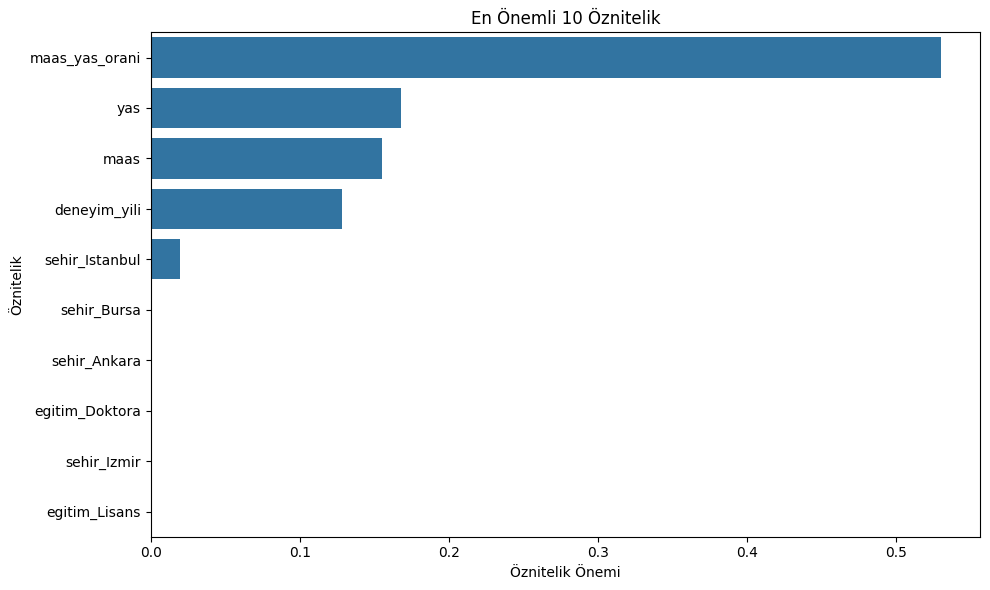

In [55]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="onem",
    y="ozellik"
)

plt.title("En Önemli 10 Öznitelik")
plt.xlabel("Öznitelik Önemi")
plt.ylabel("Öznitelik")

plt.tight_layout()
plt.show()

In [56]:
# Öznitelik önemleri

feature_importance = pd.DataFrame({
    "ozellik": X_train.columns,
    "onem": tree_model.feature_importances_
}).sort_values("onem", ascending=False)

print("Öznitelik Önemleri:")
display(feature_importance)

Öznitelik Önemleri:


,ozellik,onem
11,maas_yas_orani,0.529649
0,yas,0.167723
1,maas,0.154820
2,deneyim_yili,0.128081
5,sehir_Istanbul,0.019727
4,sehir_Bursa,0.000000
3,sehir_Ankara,0.000000
7,egitim_Doktora,0.000000
6,sehir_Izmir,0.000000
8,egitim_Lisans,0.000000


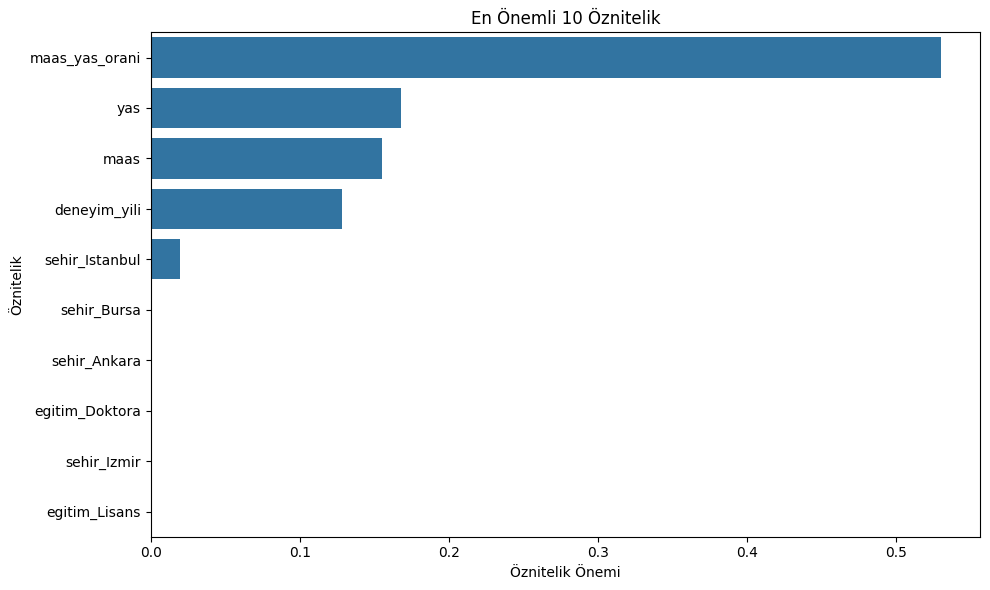

In [57]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="onem",
    y="ozellik"
)

plt.title("En Önemli 10 Öznitelik")
plt.xlabel("Öznitelik Önemi")
plt.ylabel("Öznitelik")

plt.tight_layout()
plt.show()

### Model Sonuçlarının Yorumu

Validation sonuçlarına göre Logistic Regression modeli en yüksek performansı göstermiştir. Model, 0.9556 doğruluk ve 0.9667 F1-score elde etmiştir. KNN modeli diğer modellere göre daha düşük performans gösterirken, Decision Tree modeli Logistic Regression'ın gerisinde ancak KNN'nin üzerinde sonuç vermiştir.

Cross Validation sonucunda Logistic Regression modelinin ortalama F1-score değeri yaklaşık 0.90 olarak bulunmuştur. Grid Search sonucunda en iyi parametreler C=1 ve solver=liblinear olarak belirlenmiştir.

Test verisi üzerinde model yaklaşık %91 doğruluk elde etmiştir. Precision, recall ve F1-score değerleri de modelin sınıflandırma performansının genel olarak iyi olduğunu göstermektedir.

### Modelin Sınırlılıkları

Bu çalışmada kullanılan veri seti küçük ve oluşturulmuş bir veri setidir. Bu nedenle elde edilen sonuçlar gerçek dünyadaki müşteri davranışlarını tamamen temsil etmeyebilir. Daha büyük ve gerçek müşteri verileriyle modelin performansı yeniden değerlendirilmelidir.